<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

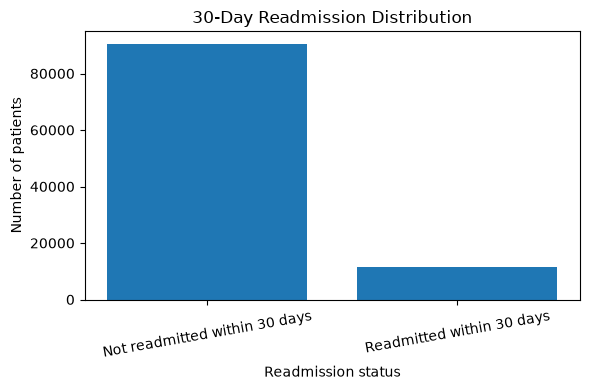

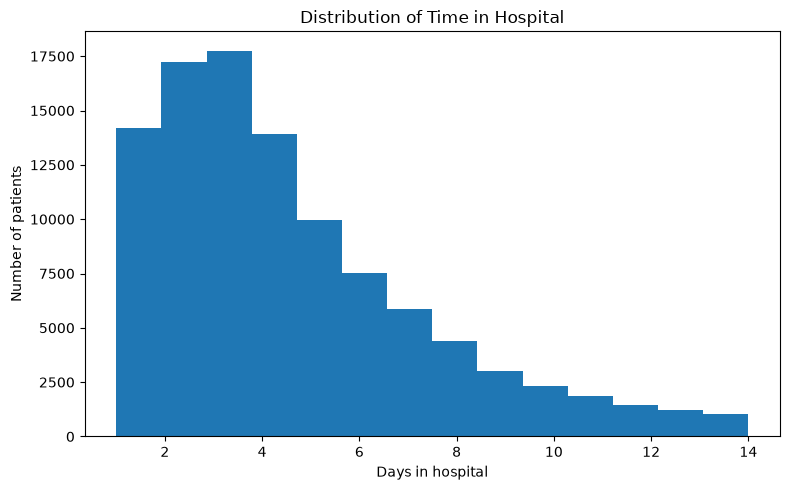

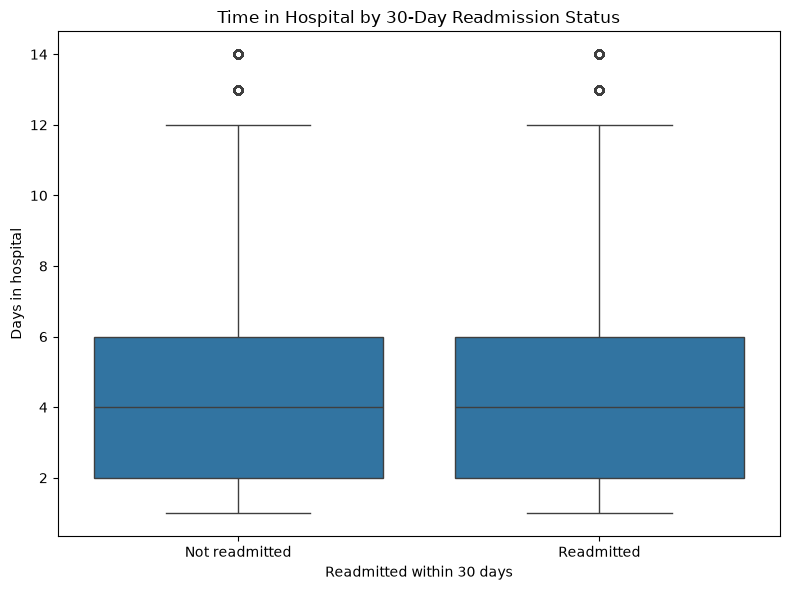

                       mean  median
readmitted_binary                  
0                  4.349224     4.0
1                  4.768249     4.0


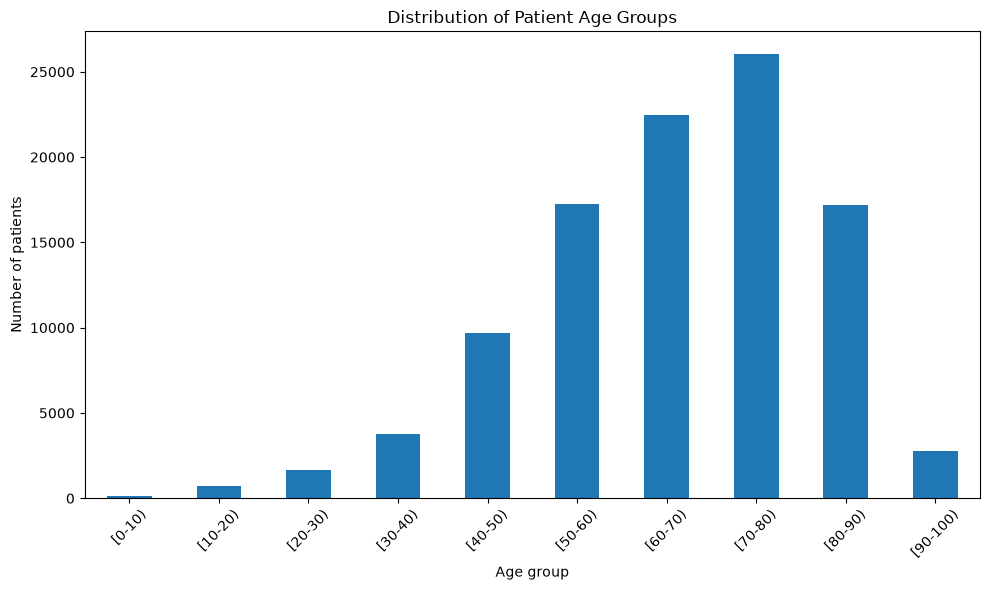

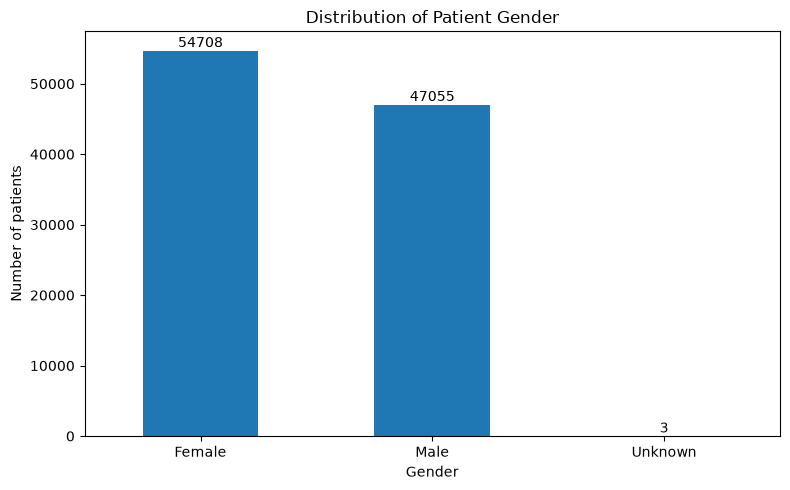

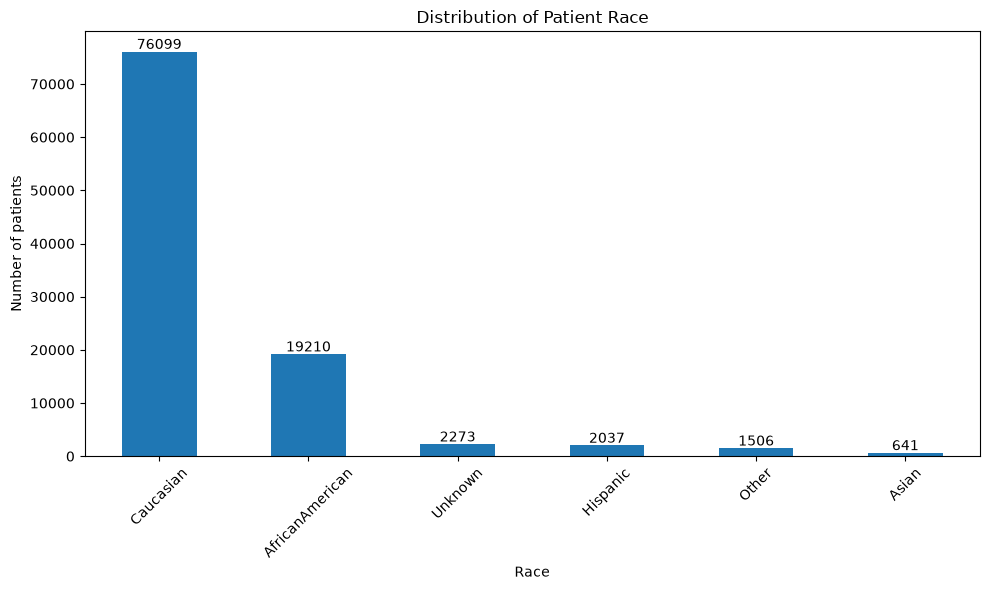

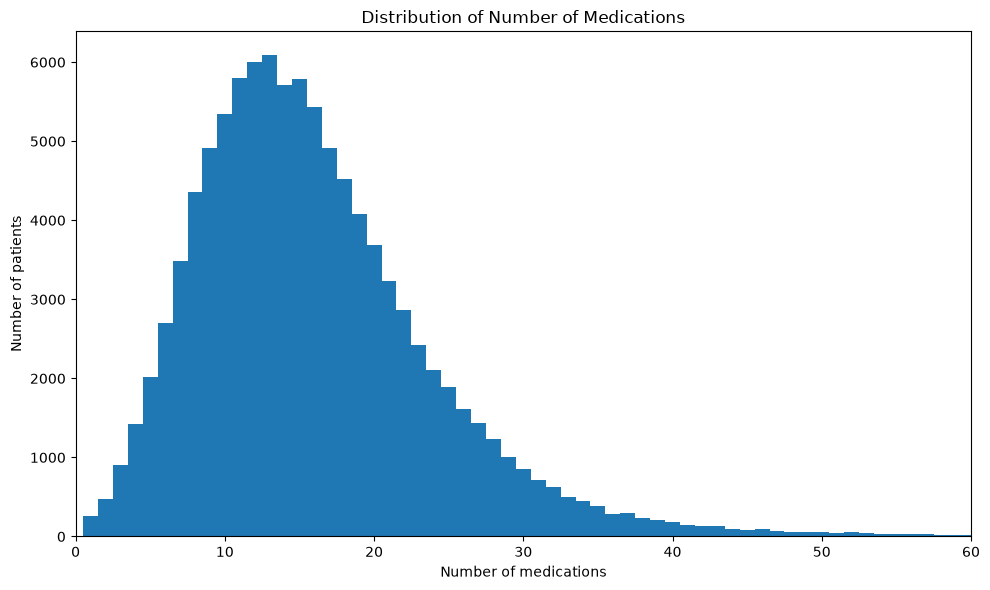

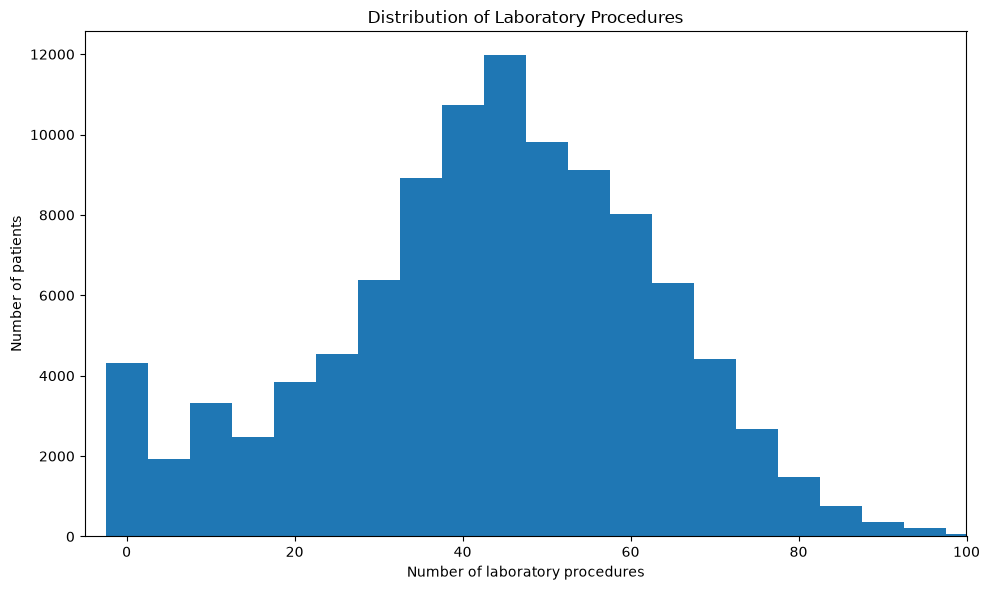

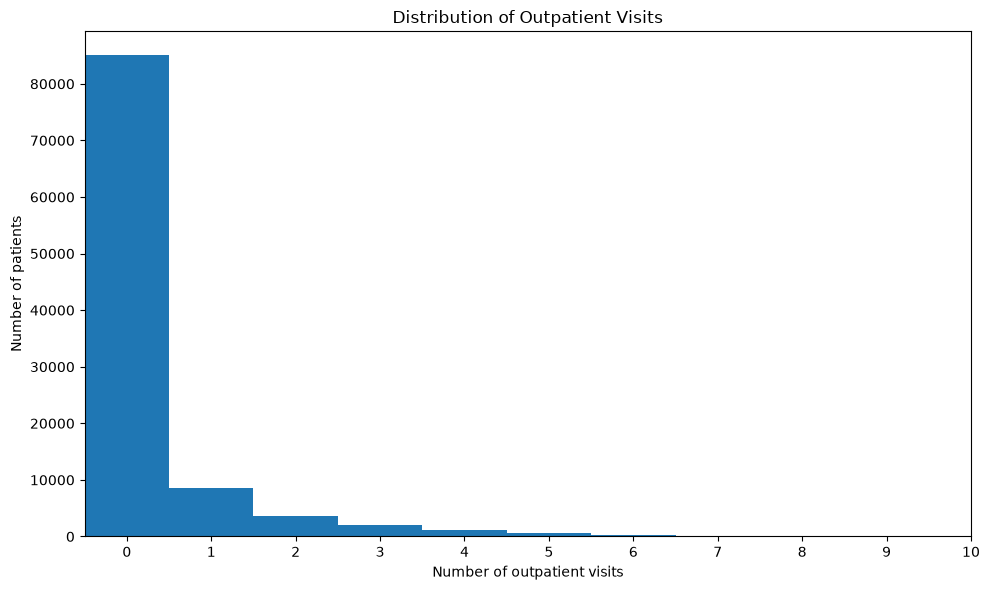

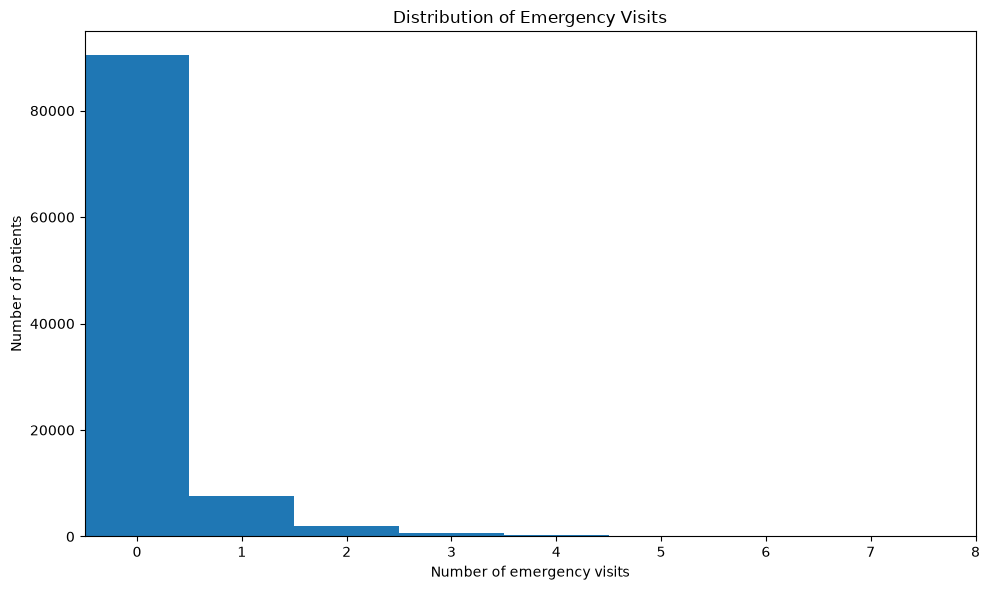

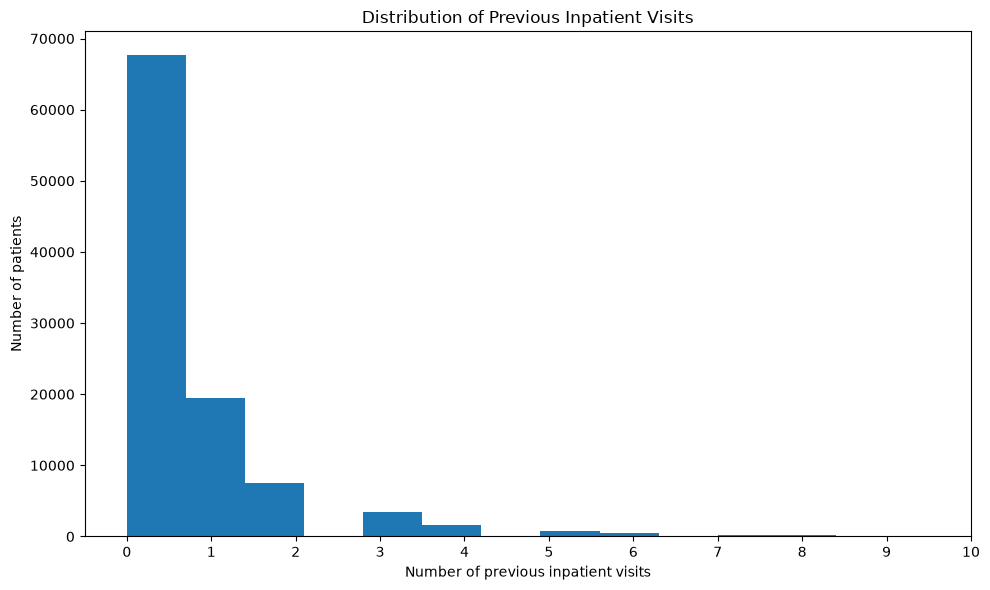

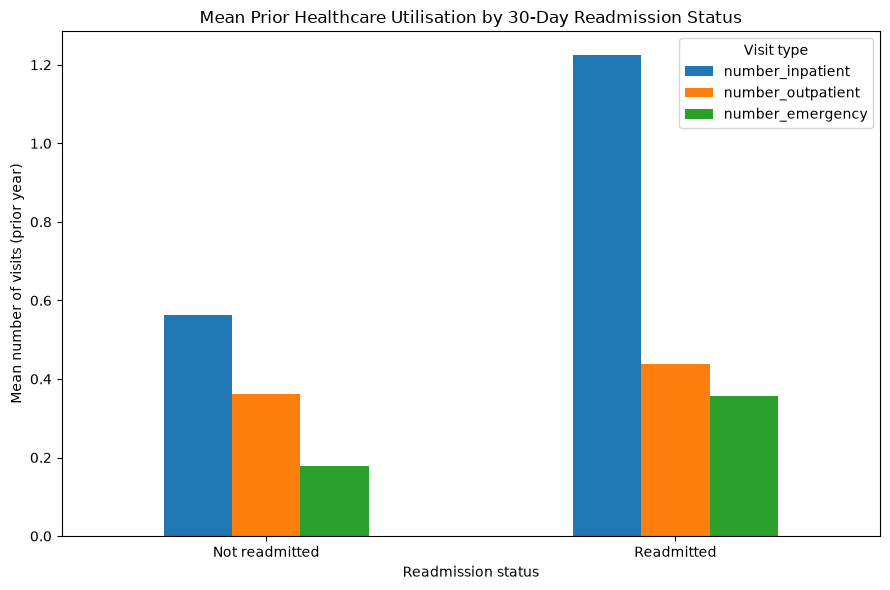

                   number_inpatient  number_outpatient  number_emergency
readmitted_binary                                                       
Not readmitted             0.561648           0.360871          0.177803
Readmitted                 1.224003           0.436911          0.357313


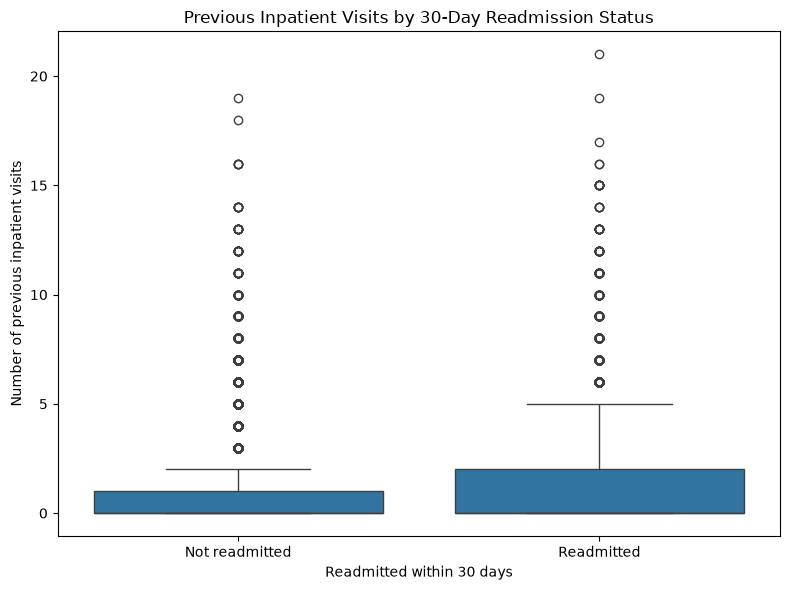

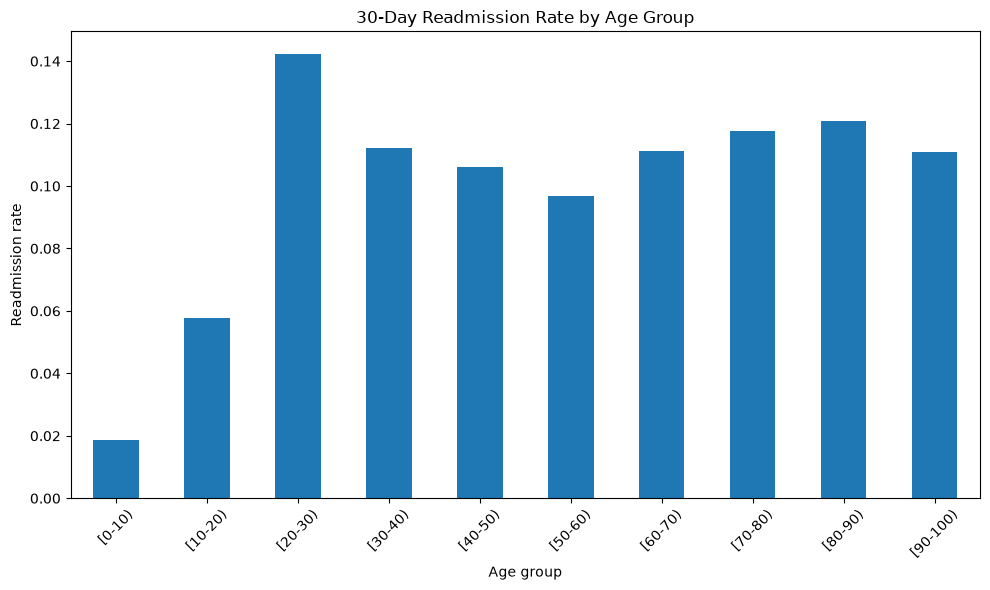

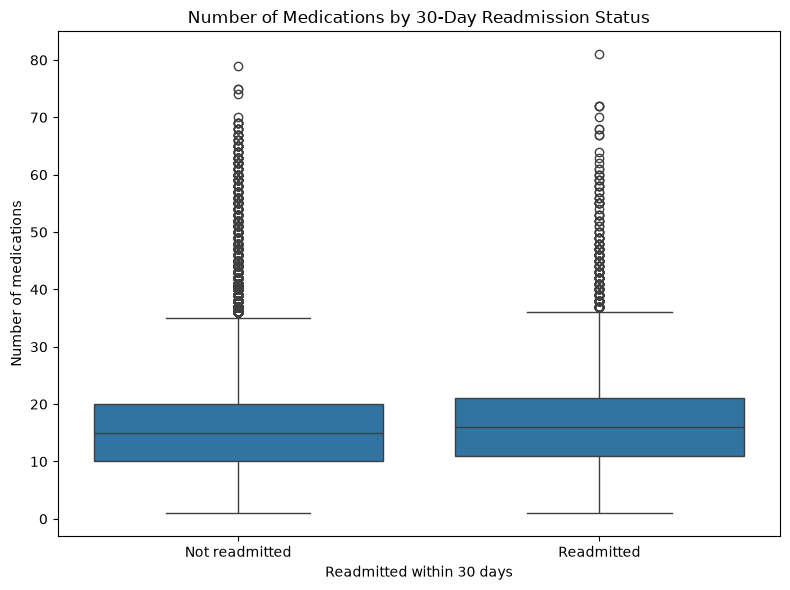

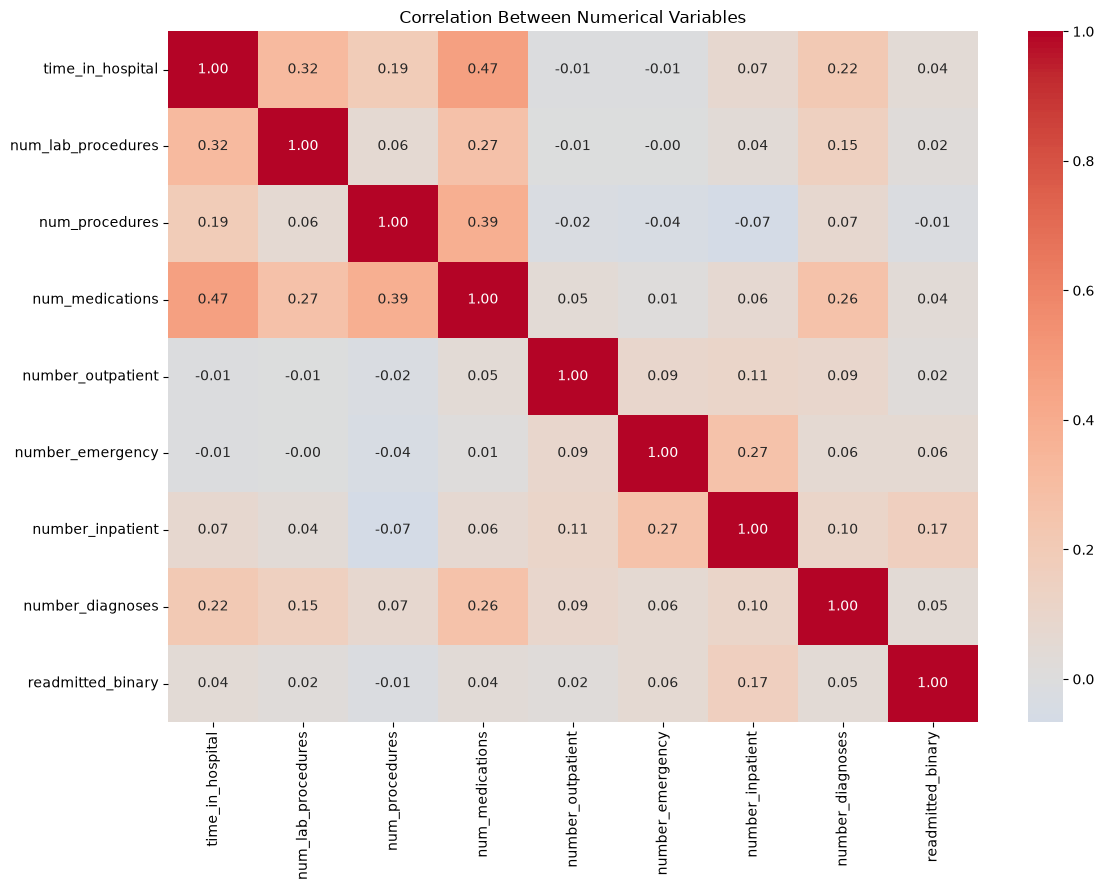

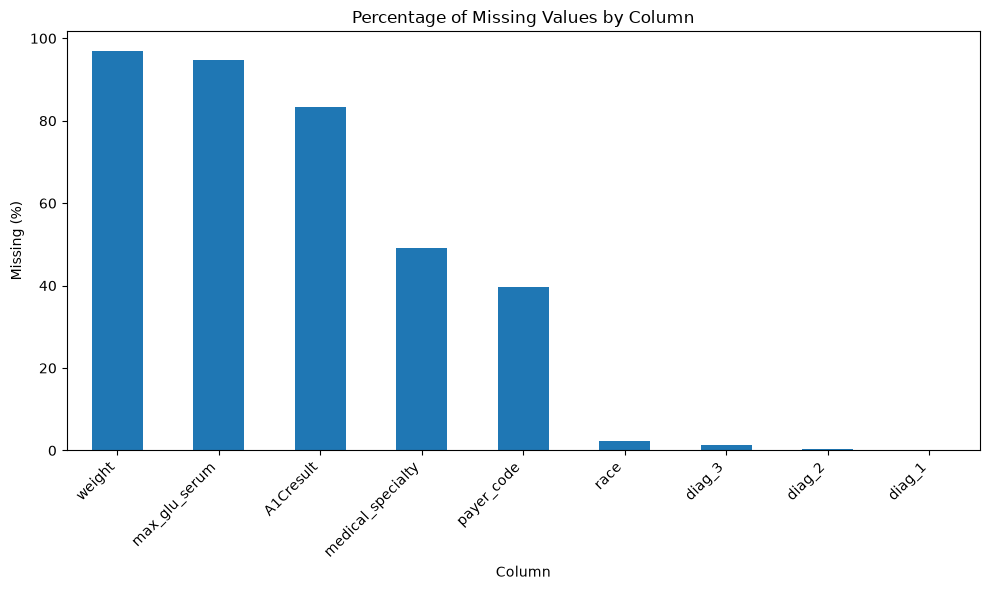

In [143]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Load Raw Data

# Load the original dataset
df = pd.read_csv("../diabetes/diabetic_data.csv")

# Create a protected copy of the raw dataset
df_raw = df.copy()

# Create a separate dataset for cleaning
df_clean = df_raw.copy()


# ============================================================
# INITIAL DATA INSPECTION
# ============================================================

# Display the first five rows
df_raw.head()

# Display number of rows and columns
df_raw.shape

# Display information about columns and data types
df_raw.info(verbose=True)

# Check for standard missing values
df_raw.isnull().sum()


# ============================================================
# IDENTIFY UNKNOWN VALUES
# ============================================================

# Count values represented by "?"
question_mark_count = (df_raw == "?").sum()

# Calculate percentage of "?" values
question_mark_percent = (question_mark_count / len(df_raw)) * 100

# Create a summary table
question_mark_summary = pd.DataFrame({
    "Unknown (?)": question_mark_count,
    "Percentage": question_mark_percent
})

# Display columns containing "?" values
question_mark_summary[
    question_mark_summary["Unknown (?)"] > 0
].sort_values(
    "Percentage",
    ascending=False
)

# ============================================================
# CHECK CATEGORICAL VARIABLES
# ============================================================
# Examine race distribution
df_raw["race"].value_counts()

# Examine gender distribution
df_raw["gender"].value_counts()

# Examine age distribution
df_raw["age"].value_counts()

# Examine target variable distribution
df_raw["readmitted"].value_counts()

# ============================================================
# CHECK ALL CATEGORICAL VARIABLES FOR INCONSISTENCIES
# ============================================================
categorical_cols = df_raw.select_dtypes(include=["object", "str"]).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df_raw[col].value_counts(dropna=False))

# ============================================================
# CHECK FOR DUPLICATES
# ============================================================
# Count duplicate rows
print("Duplicate rows found:", df_raw.duplicated().sum())
# No duplicate records found — no rows removed.



# ============================================================
# SUMMARY STATISTICS
# ============================================================

# Display summary statistics for numerical variables
df_raw.describe()


# ============================================================
# CONVERT UNKNOWN VALUES TO MISSING VALUES
# ============================================================

# Replace "?" with NaN in the clean dataset only
df_clean = df_clean.replace("?", np.nan)

# Check missing values after conversion
missing_count = df_clean.isnull().sum()

# Calculate percentage of missing values
missing_percent = (missing_count / len(df_clean)) * 100

# Create missing-value summary
missing_summary = pd.DataFrame({
    "Missing": missing_count,
    "Percentage": missing_percent
})

# Display columns containing missing values
missing_summary[
    missing_summary["Missing"] > 0
].sort_values(
    "Percentage",
    ascending=False
)

# Treat missing categorical values as an Unknown category
df_clean["medical_specialty"] = df_clean["medical_specialty"].fillna("Unknown")
df_clean["payer_code"] = df_clean["payer_code"].fillna("Unknown")

# ============================================================
# FEATURE RELEVANCE
# ============================================================

from scipy.stats import chi2_contingency

# Calculate chi-square and Cramér's V
def cramers_v(column, target):

    contingency = pd.crosstab(
        df_clean[column],
        df_clean[target]
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.sum().sum()
    min_dimension = min(contingency.shape) - 1

    v = np.sqrt((chi2 / n) / min_dimension)

    return chi2, p, v


# Test the relationship between categorical features and readmission
for column in ["medical_specialty", "payer_code"]:

    chi2, p, v = cramers_v(
        column,
        "readmitted"
    )

    print(f"{column}")
    print(f"Chi-square: {chi2:.2f}")
    print(f"p-value: {p:.4f}")
    print(f"Cramér's V: {v:.4f}")



# ============================================================
# OUTLIER IDENTIFICATION
# ============================================================
# Identify numerical columns

numerical_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Calculate IQR boundaries for each numerical column
for column in numerical_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    print(f"\n{column}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of potential outliers: {len(outliers)}")


# ============================================================
# INVESTIGATE POTENTIAL OUTLIERS
# ============================================================

# Examine upper-bound outlier values
for column in [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR

    print(f"\n{column}")
    print(
        df_clean[
            df_clean[column] > upper_bound
        ][column]
        .value_counts()
        .sort_index()
    )

# ============================================================
# HANDLE INVALID AND MISSING CATEGORICAL VALUES
# ============================================================

# Check gender values including invalid values
print("Gender values:")
print(df_clean["gender"].value_counts(dropna=False))

# Replace invalid gender values with Unknown
df_clean["gender"] = df_clean["gender"].replace(
    "Unknown/Invalid",
    "Unknown"
)

# Check race values including missing values
print("\nRace values:")
print(df_clean["race"].value_counts(dropna=False))

# Replace missing race values with Unknown
df_clean["race"] = df_clean["race"].fillna("Unknown")

# ============================================================
# OUTLIER DECISION
# ============================================================

# Review the maximum values of numerical features
print(df_clean[numerical_columns].max())

# ============================================================
# REMOVE FEATURES WITH HIGH VOLUME MISSING OR WEAK RELEVANCE
# ============================================================

df_clean = df_clean.drop(columns=[
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
])

# ============================================================
# CHECK CLEANED DATASET
# ============================================================

# Check the number of rows and columns
print("Dataset shape:", df_clean.shape)

# Check remaining missing values
print("\nRemaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Display remaining columns
print("\nRemaining columns:")
print(df_clean.columns.tolist())

# ============================================================
# HANDLE MISSING DIAGNOSIS VALUES
# ============================================================

# Replace missing diagnosis codes with Unknown
for column in ["diag_1", "diag_2", "diag_3"]:
    df_clean[column] = df_clean[column].fillna("Unknown")

# Check that no missing values remain in diagnosis columns
print(df_clean[["diag_1", "diag_2", "diag_3"]].isnull().sum())

# ============================================================
# REMOVE IDENTIFIER COLUMNS
# ============================================================

# Remove patient and encounter identifiers
df_clean = df_clean.drop(columns=[
    "encounter_id",
    "patient_nbr"
])

# Check the new dataset shape
print("Dataset shape:", df_clean.shape)

# ============================================================
# CREATE BINARY READMISSION TARGET
# ============================================================

# Convert readmission into a binary target
# 1 = readmitted within 30 days
# 0 = not readmitted within 30 days

df_clean["readmitted_binary"] = df_clean["readmitted"].map({
    "<30": 1,
    ">30": 0,
    "NO": 0
})

# Check the new target distribution
print(df_clean["readmitted_binary"].value_counts())

# ============================================================
# REMOVE ORIGINAL READMISSION VARIABLE
# ============================================================

# Remove the original three-class readmission variable
df_clean = df_clean.drop(columns=["readmitted"])

# Check the final target
print(df_clean["readmitted_binary"].value_counts())

# ============================================================
# FINAL CLEAN DATA CHECK
# ============================================================

# Check final dataset shape
print("Final dataset shape:", df_clean.shape)

# Check for remaining missing values
print("\nRemaining missing values:")
print(df_clean.isnull().sum().sum())

# Check target distribution
print("\nReadmission target:")
print(df_clean["readmitted_binary"].value_counts())

# Check data types
print("\nData types:")
print(df_clean.dtypes)

# ============================================================
# EXPORT CLEANED DATASET
# ============================================================
df_clean.to_csv("diabetic_data_clean.csv", index=False)

# TASK 4: EXPLORATORY DATA ANALYSIS

# TARGET VARIABLE DISTRIBUTION
# Count patients in each readmission category
readmission_counts = df_clean["readmitted_binary"].value_counts()

# Create bar chart
plt.figure(figsize=(6, 4))

plt.bar(
    ["Not readmitted within 30 days", "Readmitted within 30 days"],
    readmission_counts.reindex([0, 1])
)

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmission status")
plt.ylabel("Number of patients")
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()


# ============================================================
# NUMERICAL VARIABLE DISTRIBUTION
# ============================================================

# Distribution of time spent in hospital
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["time_in_hospital"],
    bins=14
)

plt.title("Distribution of Time in Hospital")
plt.xlabel("Days in hospital")
plt.ylabel("Number of patients")

plt.tight_layout()
plt.show()

 # ============================================================
# TIME IN HOSPITAL VS 30-DAY READMISSION
# ============================================================
plt.figure(figsize=(8, 6))
sns.boxplot(
    x="readmitted_binary",
    y="time_in_hospital",
    data=df_clean
)
plt.title("Time in Hospital by 30-Day Readmission Status")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Days in hospital")
plt.xticks([0, 1], ["Not readmitted", "Readmitted"])
plt.tight_layout()
plt.show()

# Boxes look near-identical — confirm with actual numbers
print(df_clean.groupby("readmitted_binary")["time_in_hospital"].agg(["mean", "median"]))

# ============================================================
# AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

df_clean["age"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Patient Age Groups")
plt.xlabel("Age group")
plt.ylabel("Number of patients")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#GENDER DISTRIBUTION
plt.figure(figsize=(8, 5))
gender_counts = df_clean["gender"].value_counts()
ax = gender_counts.plot(kind="bar")

for i, v in enumerate(gender_counts):
    ax.text(i, v + 500, str(v), ha="center")

plt.title("Distribution of Patient Gender")
plt.xlabel("Gender")
plt.ylabel("Number of patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# ============================================================
# RACE DISTRIBUTION
# ============================================================
plt.figure(figsize=(10, 6))
race_counts = df_clean["race"].value_counts()
ax = race_counts.plot(kind="bar")

for i, v in enumerate(race_counts):
    ax.text(i, v + 500, str(v), ha="center")

plt.title("Distribution of Patient Race")
plt.xlabel("Race")
plt.ylabel("Number of patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# DISTRIBUTION OF NUMBER OF MEDICATIONS
# ============================================================
plt.figure(figsize=(10, 6))
plt.hist(
    df_clean["num_medications"],
    bins=np.arange(
        df_clean["num_medications"].min() - 0.5,
        df_clean["num_medications"].max() + 1.5,
        1
    )
)
plt.title("Distribution of Number of Medications")
plt.xlabel("Number of medications")
plt.ylabel("Number of patients")
plt.xlim(0, 60)
plt.tight_layout()
plt.show()

# ============================================================
# DISTRIBUTION OF LABORATORY PROCEDURES
# ============================================================
plt.figure(figsize=(10, 6))
max_val = df_clean["num_lab_procedures"].max()
plt.hist(
    df_clean["num_lab_procedures"],
    bins=np.arange(-2.5, max_val + 5, 5)  # width-5 bins, evenly spaced
)
plt.title("Distribution of Laboratory Procedures")
plt.xlabel("Number of laboratory procedures")
plt.ylabel("Number of patients")
plt.xlim(-5, 100)
plt.tight_layout()
plt.show()

# ============================================================
# DISTRIBUTION OF OUTPATIENT VISITS
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["number_outpatient"],
    bins=np.arange(-0.5, 10.5, 1)
)

plt.title("Distribution of Outpatient Visits")
plt.xlabel("Number of outpatient visits")
plt.ylabel("Number of patients")

plt.xlim(-0.5, 10)

plt.xticks(range(0, 11))

plt.tight_layout()
plt.show()

# ============================================================
# DISTRIBUTION OF EMERGENCY VISITS
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["number_emergency"],
    bins=np.arange(-0.5, 5.5, 1)
)

plt.title("Distribution of Emergency Visits")
plt.xlabel("Number of emergency visits")
plt.ylabel("Number of patients")

plt.xlim(-0.5, 8)

plt.xticks(range(0, 9))

plt.tight_layout()
plt.show()
# ============================================================
# DISTRIBUTION OF PREVIOUS INPATIENT VISITS
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(df_clean["number_inpatient"], bins=30)

plt.title("Distribution of Previous Inpatient Visits")
plt.xlabel("Number of previous inpatient visits")
plt.ylabel("Number of patients")

plt.xlim(-0.5, 10 )

plt.xticks(range(0, 11))

plt.tight_layout()
plt.show()
# ============================================================
# PRIOR HEALTHCARE UTILISATION VS 30-DAY READMISSION
# ============================================================
utilisation_cols = ["number_inpatient", "number_outpatient", "number_emergency"]

utilisation_by_target = (
    df_clean.groupby("readmitted_binary")[utilisation_cols]
    .mean()
    .rename(index={0: "Not readmitted", 1: "Readmitted"})
)

utilisation_by_target.plot(kind="bar", figsize=(9, 6))
plt.title("Mean Prior Healthcare Utilisation by 30-Day Readmission Status")
plt.xlabel("Readmission status")
plt.ylabel("Mean number of visits (prior year)")
plt.xticks(rotation=0)
plt.legend(title="Visit type")
plt.tight_layout()
plt.show()

print(utilisation_by_target)

# ============================================================
# PREVIOUS INPATIENT VISITS VS 30-DAY READMISSION
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="readmitted_binary",
    y="number_inpatient",
    data=df_clean
)

plt.title("Previous Inpatient Visits by 30-Day Readmission Status")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of previous inpatient visits")

plt.xticks(
    [0, 1],
    ["Not readmitted", "Readmitted"]
)

plt.tight_layout()
plt.show()

# ============================================================
# READMISSION RATE BY AGE GROUP
# ============================================================

readmission_by_age = (
    df_clean.groupby("age")["readmitted_binary"]
    .mean()
    .reindex([
        "[0-10)",
        "[10-20)",
        "[20-30)",
        "[30-40)",
        "[40-50)",
        "[50-60)",
        "[60-70)",
        "[70-80)",
        "[80-90)",
        "[90-100)"
    ])
)

plt.figure(figsize=(10, 6))

readmission_by_age.plot(kind="bar")

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age group")
plt.ylabel("Readmission rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# MEDICATIONS VS 30-DAY READMISSION
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="readmitted_binary",
    y="num_medications",
    data=df_clean
)

plt.title("Number of Medications by 30-Day Readmission Status")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of medications")

plt.xticks(
    [0, 1],
    ["Not readmitted", "Readmitted"]
)

plt.tight_layout()
plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

correlation_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "readmitted_binary"
]

correlation_matrix = df_clean[correlation_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numerical Variables")

plt.tight_layout()
plt.show()








# ============================================================
# MISSING VALUE VISUALISATION
# ============================================================
missing_percent_raw = (df_raw.replace("?", np.nan).isnull().sum() / len(df_raw)) * 100
missing_percent_raw = missing_percent_raw[missing_percent_raw > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing_percent_raw.plot(kind="bar")
plt.title("Percentage of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
